In [32]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.ndimage import gaussian_filter, laplace
# from scipy.fftpack import dct, idct

In [33]:
def smooth_with_detail_enhance(data, sigma=3.0, alpha=0.3):
    """
    高斯平滑与细节增强组合处理
    参数：
    sigma: 高斯核标准差 (控制平滑强度)
    alpha: 细节增强系数 (0.1-0.5)
    """
    # 转换为numpy数组
    data_np = data.values if isinstance(data, xr.DataArray) else data
    
    # 高斯平滑
    smoothed = gaussian_filter(data_np, sigma=sigma)
    
    # 细节提取与增强
    detail = data_np - smoothed
    enhanced = smoothed + alpha * detail
    
    # 保持数据范围
    if isinstance(data, xr.DataArray):
        return xr.DataArray(enhanced, dims=data.dims, coords=data.coords)
    else:
        return enhanced
    
# 各向异性扩散滤波（消除马赛克边界）
def anisotropic_diffusion(u, iterations=10, kappa=50, gamma=0.1):
    u = u.copy()
    for _ in range(iterations):
        grad_north = np.roll(u, -1, axis=0) - u
        grad_south = np.roll(u, 1, axis=0) - u
        grad_east = np.roll(u, -1, axis=1) - u
        grad_west = np.roll(u, 1, axis=1) - u
        
        cN = np.exp(-(grad_north/kappa)**2)
        cS = np.exp(-(grad_south/kappa)**2)
        cE = np.exp(-(grad_east/kappa)**2)
        cW = np.exp(-(grad_west/kappa)**2)
        
        u += gamma * (cN*grad_north + cS*grad_south + cE*grad_east + cW*grad_west)
    return u

# 边缘增强处理
def enhance_details(img, alpha=2.0):
    lowpass = gaussian_filter(img, sigma=2)
    highpass = img - lowpass
    return img + alpha * highpass

# 对比度拉伸
def contrast_stretch(img, lower=2, upper=98):
    plow, phigh = np.percentile(img, (lower, upper))
    return (img - plow) / (phigh - plow)


In [34]:
path = r'C:\Users\0\Desktop\0_tcco2.nc'################################################################################################## 更改路径
ds = xr.open_dataset(path)
co2_data = np.array(ds['tcco2'])
lon = np.array(ds['lon'])
lat = np.array(ds['lat'])
X,Y = np.meshgrid(lat,lon, indexing='ij')

# 处理流程
processed = smooth_with_detail_enhance(co2_data, sigma=8.0, alpha=0.5)
# processed = anisotropic_diffusion(co2_data, iterations=30, kappa=12)
# processed = enhance_details(processed, alpha=0.9)
# processed = np.clip(contrast_stretch(processed), 0, 1)
save_data = np.hstack((X.reshape(-1,1), Y.reshape(-1,1), processed.reshape(-1,1)))
np.savetxt(r'C:\Users\0\Desktop\0_tcco2.csv', save_data,delimiter=',')#################################################################### 更改路径

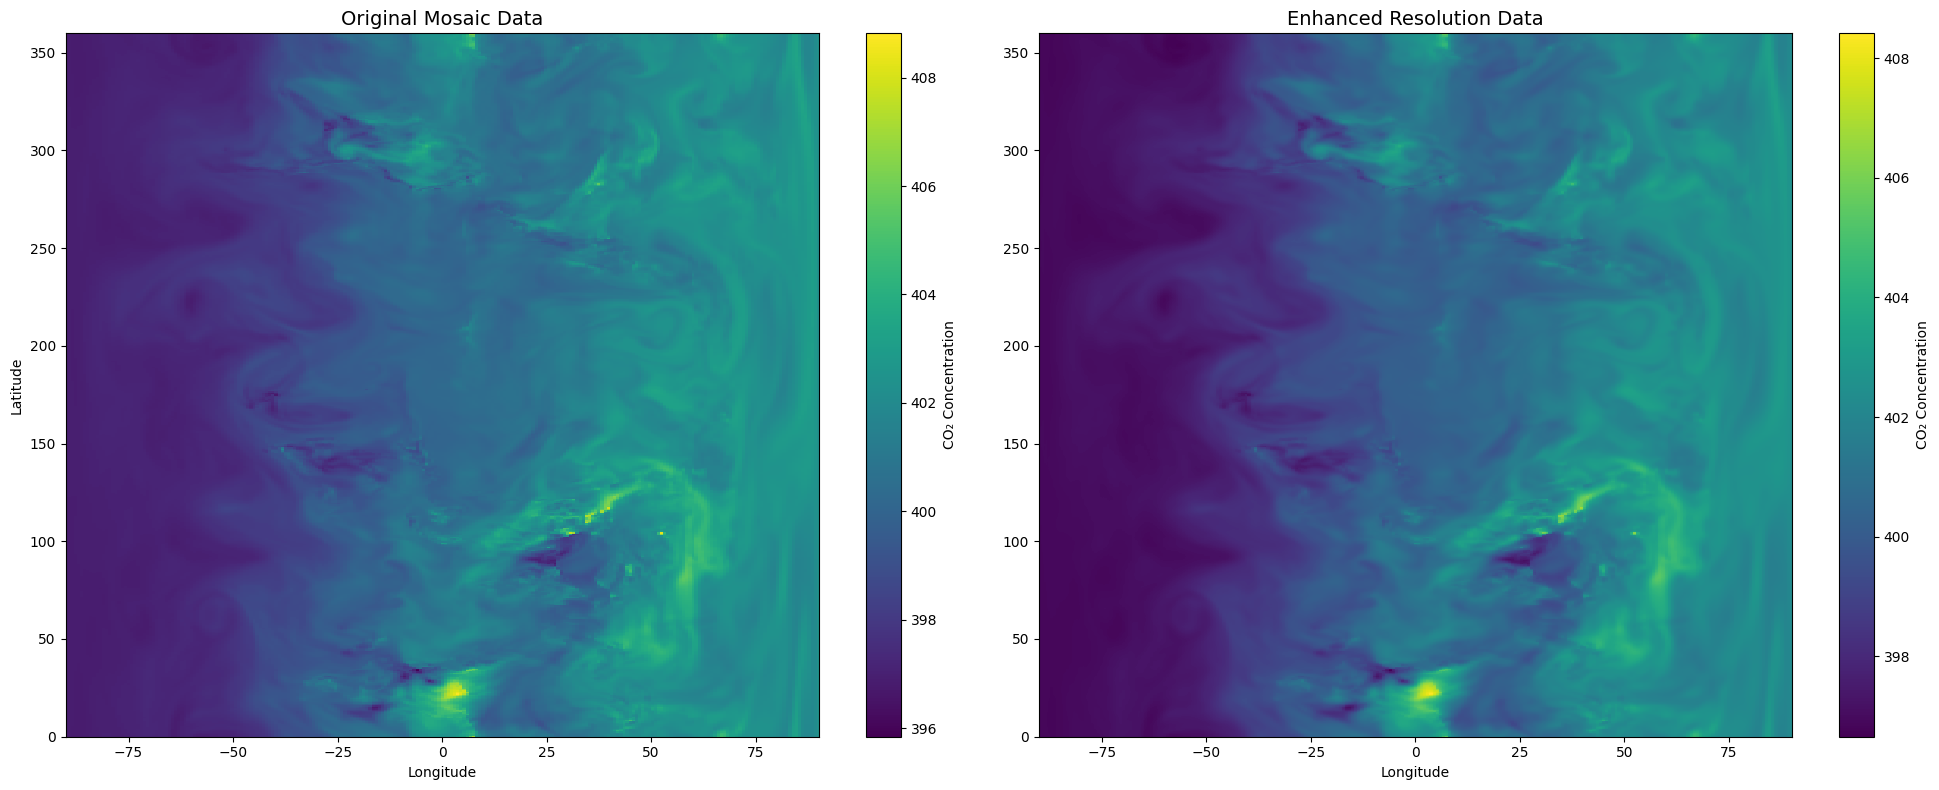

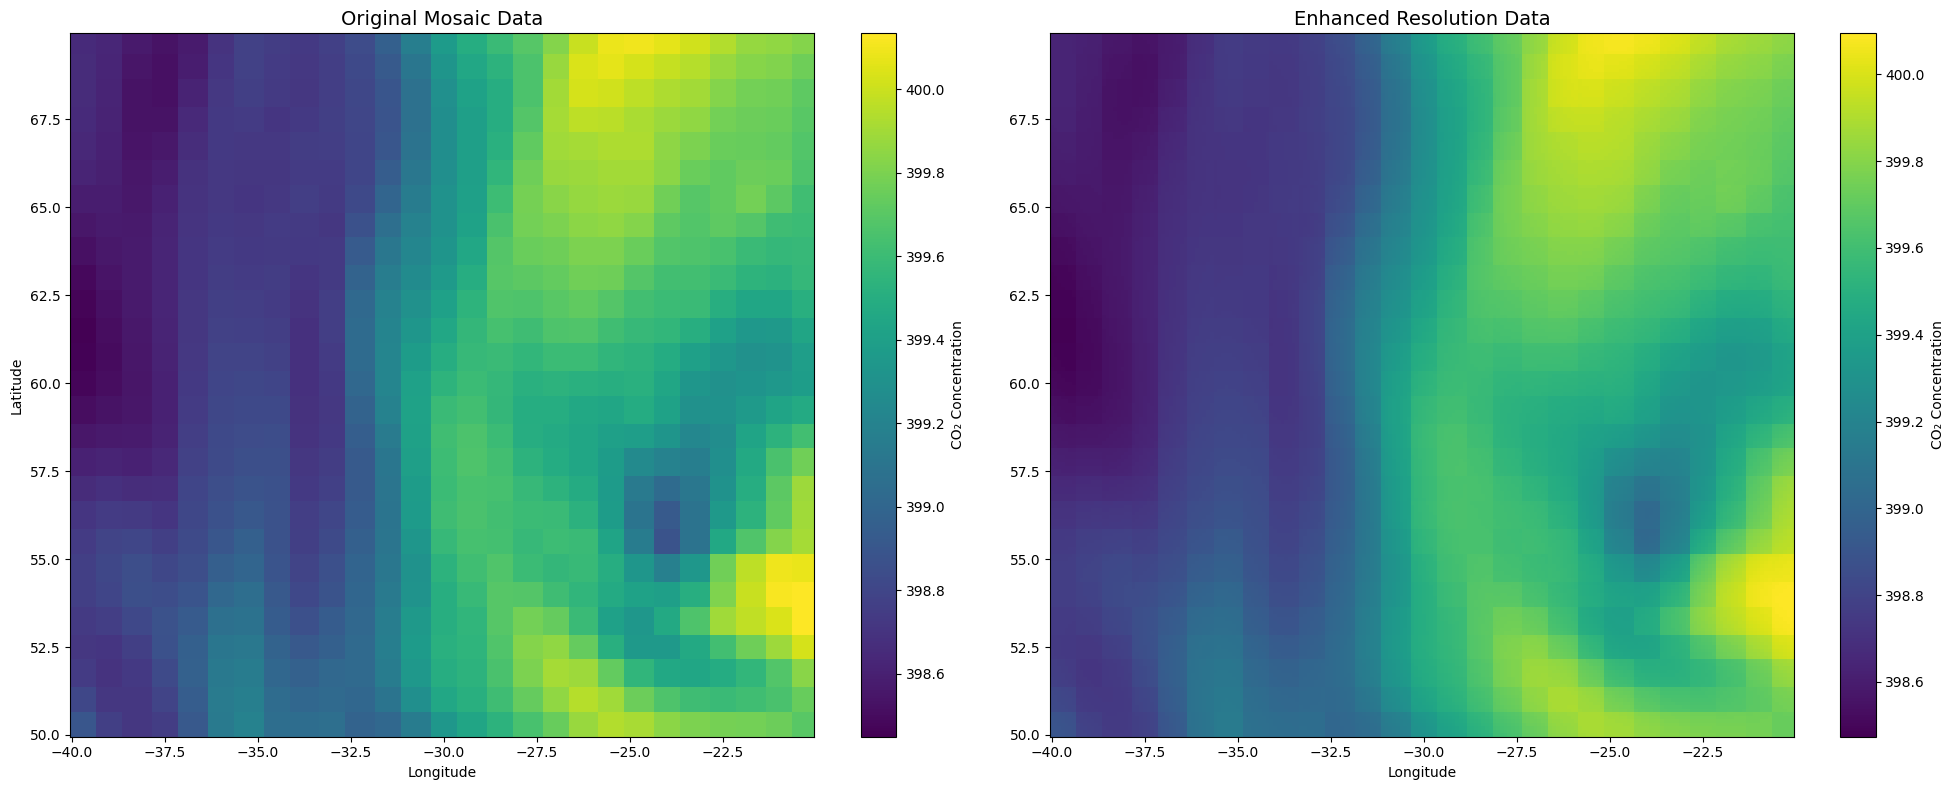

In [35]:
###下面不用运行
################################################################################################################
# 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 原始数据
im1 = ax1.pcolormesh(X, Y, co2_data, cmap='viridis', shading='auto')
ax1.set_title('Original Mosaic Data', fontsize=14)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
fig.colorbar(im1, ax=ax1, label='CO₂ Concentration')

# 处理结果
im2 = ax2.pcolormesh(X, Y, processed, cmap='viridis', shading='auto')
ax2.set_title('Enhanced Resolution Data', fontsize=14)
ax2.set_xlabel('Longitude')
fig.colorbar(im2, ax=ax2, label='CO₂ Concentration')

plt.tight_layout()
plt.show()

# 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 原始数据
im1 = ax1.pcolormesh(X[500:700,500:700], Y[500:700,500:700], co2_data[500:700,500:700], cmap='viridis', shading='auto')
ax1.set_title('Original Mosaic Data', fontsize=14)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
fig.colorbar(im1, ax=ax1, label='CO₂ Concentration')

# 处理结果
im2 = ax2.pcolormesh(X[500:700,500:700], Y[500:700,500:700], processed[500:700,500:700], cmap='viridis', shading='auto')
ax2.set_title('Enhanced Resolution Data', fontsize=14)
ax2.set_xlabel('Longitude')
fig.colorbar(im2, ax=ax2, label='CO₂ Concentration')

plt.tight_layout()
plt.show()